# 1.1 BO-qLogEI (q=5)

/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([-0.0539], device='cuda:0', dtype=torch.float64), std = tensor([0.3607], device='cuda:0', dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


candidate: tensor([[0.3522],
        [0.0000],
        [0.7689],
        [1.8711],
        [0.5680]], device='cuda:0', dtype=torch.float64)
acq_value: tensor(-1.3438, device='cuda:0', dtype=torch.float64)


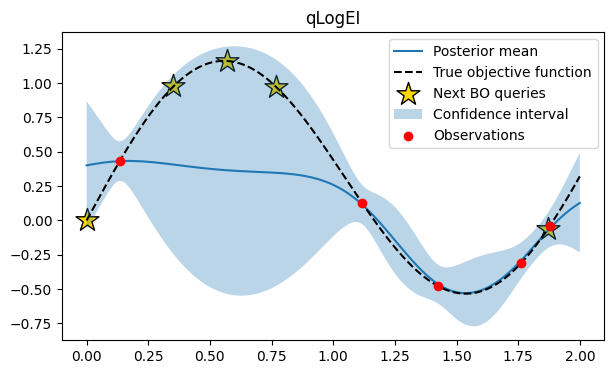

In [1]:
import torch
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogExpectedImprovement
from botorch.optim import optimize_acqf

from gpytorch.mlls import ExactMarginalLogLikelihood

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double   # 强烈推荐 double（GP 数值稳定）
print('device:', device)

def objective(x):
    # x: (n, 1)
    return torch.sin(3 * x) + 0.3 * x

torch.manual_seed(0)

# 搜索空间
bounds = torch.tensor([[0.0], [2.0]], device=device, dtype=dtype)

# Batch points
q = 5

# 初始采样点
train_x = (torch.rand(5, 1, device=device, dtype=dtype) * 2.0)
train_y = objective(train_x).to(device=device, dtype=dtype)


model = SingleTaskGP(train_x, train_y)
model = model.to(device=device, dtype=dtype)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

best_f = train_y.max()

acqf = qLogExpectedImprovement(
    model=model,
    best_f=best_f
).to(device=device, dtype=dtype)

# 评估网格
X = torch.linspace(0, 2, 500, device=device, dtype=dtype).unsqueeze(-1)
X_acq = X.unsqueeze(1)   # (500, 1, 1)

# 后验
posterior = model.posterior(X)
mean = posterior.mean.squeeze(-1).detach()
var = posterior.variance.squeeze(-1).detach()

# 获取函数
with torch.no_grad():
    log_ei = acqf(X_acq).squeeze(-1)


candidates, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=q,
    num_restarts=10,
    raw_samples=64,)

print('candidate:', candidates)
print('acq_value:', acq_value)


plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("qLogEI")
plt.legend()
plt.show()




# 2.1 BO-qEI (q=5)

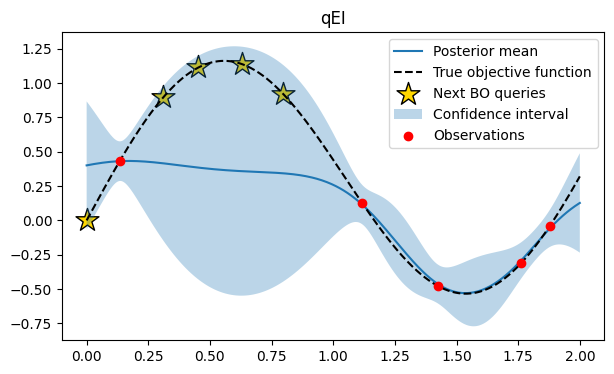

In [2]:

from botorch.acquisition.monte_carlo import qExpectedImprovement


best_f = train_y.max()

acqf = qExpectedImprovement(
    model=model,
    best_f=best_f
).to(device=device, dtype=dtype)

# 获取函数
with torch.no_grad():
    ei = acqf(X_acq).squeeze(-1)


candidates, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=5,
    num_restarts=10,
    raw_samples=64,
    )


plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("qEI")
plt.legend()
plt.show()


# 2.2 BO-qEI-KB (q=5)

/data1/qcq4123155034/CBBO


/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0158], device='cuda:0', dtype=torch.float64), std = tensor([0.3650], device='cuda:0', dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: I

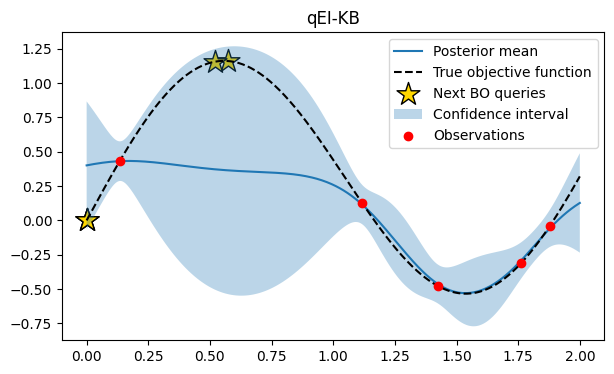

In [ ]:
import sys
import os

notebook_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..','..')) 
print(project_root)
sys.path.append(project_root)

from methods_batch.ei_batch import ei_kriging_believer

candidates = ei_kriging_believer(
    model=model,
    train_x=train_x,
    train_y=train_y,
    bounds=bounds,
    q=q
)

plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("qEI-KB")
plt.legend()
plt.show()



# 2.3 BO-qEI-CL (q=5)

/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0278], device='cuda:0', dtype=torch.float64), std = tensor([0.3796], device='cuda:0', dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: I

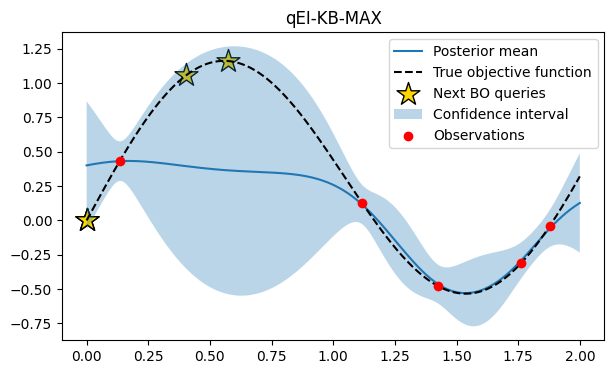

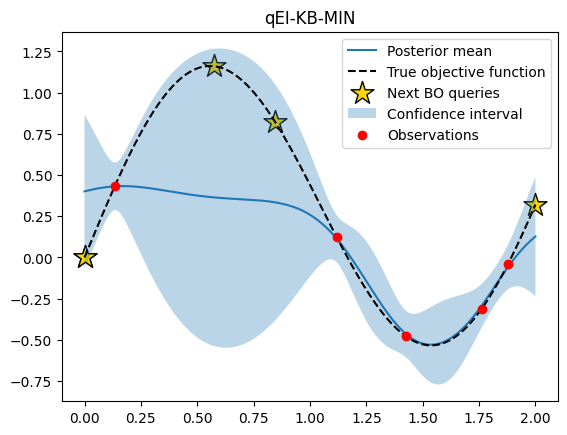

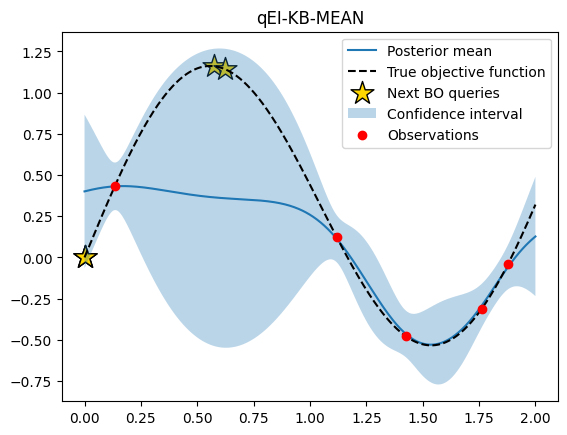

In [4]:

from methods_batch.ei_batch import ei_constant_liar

candidates_max = ei_constant_liar(
    model=model,
    train_x=train_x,
    train_y=train_y,
    bounds=bounds,
    q=q,
    style='max',
)

candidates_min = ei_constant_liar(
    model=model,
    train_x=train_x,
    train_y=train_y,
    bounds=bounds,
    q=q,
    style='min',
)

candidates_mean = ei_constant_liar(
    model=model,
    train_x=train_x,
    train_y=train_y,
    bounds=bounds,
    q=q,
    style='mean',
)

plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates_max.cpu().numpy(), objective(candidates_max).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("qEI-KB-MAX")
plt.legend()
plt.show()


plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates_min.cpu().numpy(), objective(candidates_min).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("qEI-KB-MIN")
plt.legend()
plt.show()


plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates_mean.cpu().numpy(), objective(candidates_mean).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("qEI-KB-MEAN")
plt.legend()
plt.show()


# 2.4 BO-qEI-LP

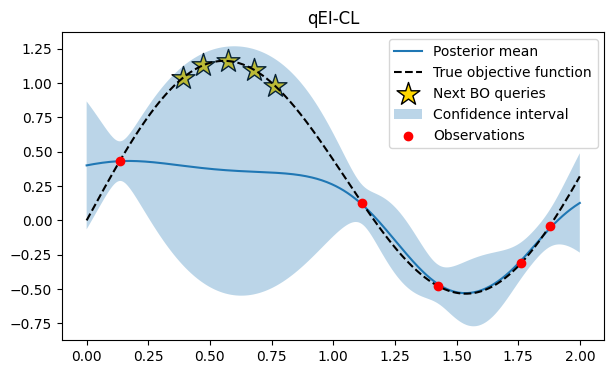

In [5]:
from methods_batch.local_penalization import optimize_acqf_with_lp
from botorch.acquisition.analytic import ExpectedImprovement

acqf = ExpectedImprovement(
    model=model,
    best_f=train_y.max(),
).to(device=device, dtype=dtype)

candidates = optimize_acqf_with_lp(
    model=model,
    base_acqf=acqf,
    bounds=bounds,
    q=5,
    L=10.0,   
)

plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("qEI-CL")
plt.legend()
plt.show()


# 3.1 BO-qUCB

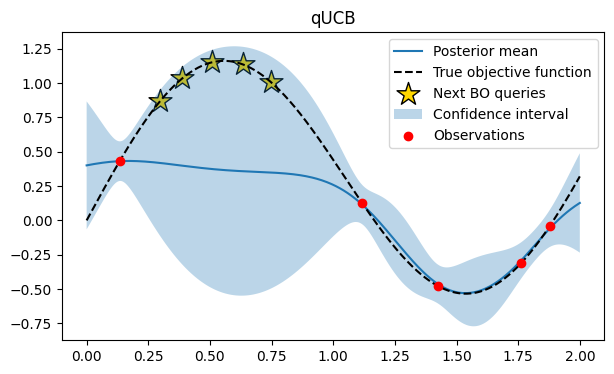

In [6]:
from botorch.acquisition.monte_carlo import qUpperConfidenceBound


acqf = qUpperConfidenceBound(
    model=model,
    beta=0.2,
).to(device=device, dtype=dtype)

candidates = optimize_acqf_with_lp(
    model=model,
    base_acqf=acqf,
    bounds=bounds,
    q=5,
)

plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("qUCB")
plt.legend()
plt.show()


# 3.2 BO-BUCB

/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0175], device='cuda:0', dtype=torch.float64), std = tensor([0.3669], device='cuda:0', dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: I

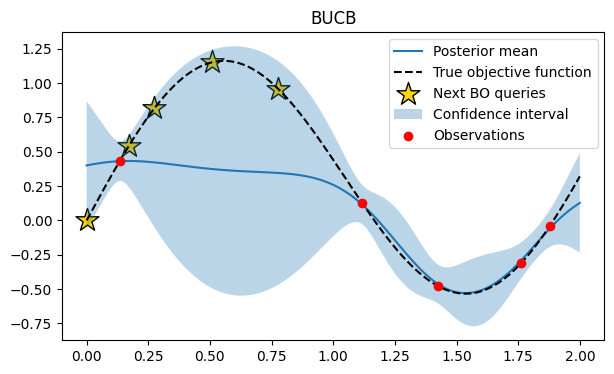

In [7]:
from methods_batch.ucb_batch import bucb


candidates = bucb(
    model=model,
    bounds=bounds,
    beta=0.2,
    q=q,
    num_restarts=1,
    raw_samples=16,
).to(device=device, dtype=dtype)

plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("BUCB")
plt.legend()
plt.show()

# 3.3 BO: GP-UCB-PE

/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0175], device='cuda:0', dtype=torch.float64), std = tensor([0.3669], device='cuda:0', dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: I

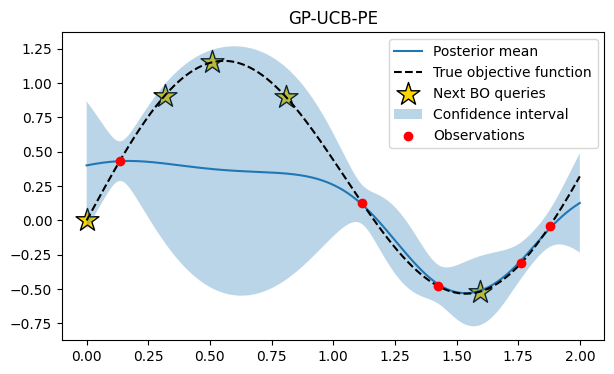

In [8]:
from methods_batch.ucb_batch import gp_ucb_pe

candidates = gp_ucb_pe(
    model=model,
    bounds=bounds,
    beta=0.2,
    q=q,
    num_restarts=1,
    raw_samples=16,
).to(device=device, dtype=dtype)

plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("GP-UCB-PE")
plt.legend()
plt.show()

# 3.4 BO-qUCB-LP

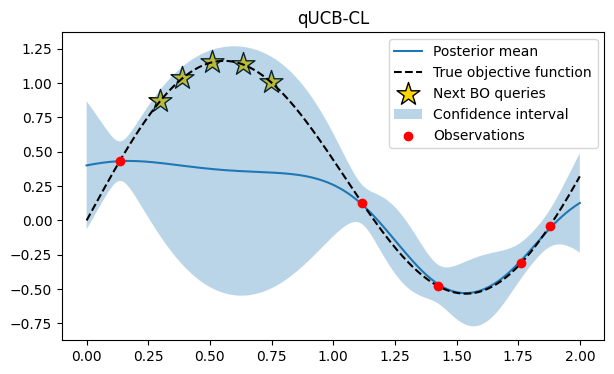

In [9]:
from methods_batch.local_penalization import optimize_acqf_with_lp
from botorch.acquisition.analytic import UpperConfidenceBound

acqf = UpperConfidenceBound(
    model=model,
    beta=0.2,
).to(device=device, dtype=dtype)

candidates = optimize_acqf_with_lp(
    model=model,
    base_acqf=acqf,
    bounds=bounds,
    q=5,
    L=10.0,   
)

plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("qUCB-CL")
plt.legend()
plt.show()


# 4.1 qKG

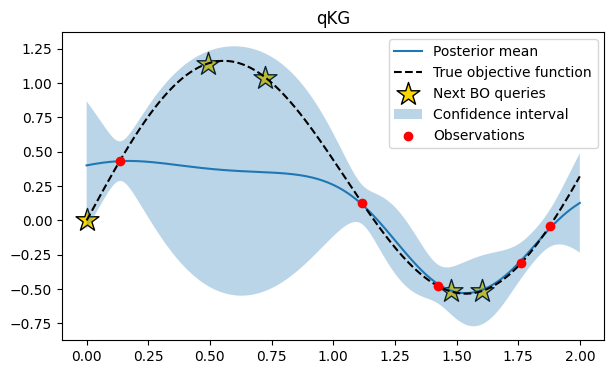

In [10]:
from botorch.acquisition.knowledge_gradient import qKnowledgeGradient

acqf = qKnowledgeGradient(
    model=model
)

candidates, _ = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=5,
    num_restarts=10,
    raw_samples=64,
)

plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("qKG")
plt.legend()
plt.show()

# 5.1 PPES

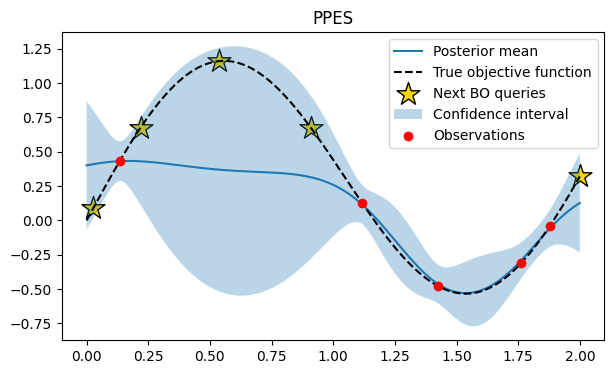

In [11]:
from botorch.acquisition.predictive_entropy_search import qPredictiveEntropySearch

from botorch.utils.sampling import draw_sobol_samples

optimal_inputs = draw_sobol_samples(
    bounds=bounds,
    n=1024,
    q=1,
).squeeze(1)   # [1024, d]

acqf = qPredictiveEntropySearch(
    model=model,
    optimal_inputs=optimal_inputs,
)

candidates, _ = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=5,
    num_restarts=10,
    raw_samples=64,   
)

plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("PPES")
plt.legend()
plt.show()

# 6.1 qMES

/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/gpytorch.py:477: BotorchTensorDimensionWarning: Non-strict enforcement of botorch tensor conventions. The following error would have been raised with strict enforcement: Expected X and Y to have the same number of dimensions (got X with dimension 2 and Y with dimension 3).
  self._validate_tensor_args(X=X, Y=Y, Yvar=noise, strict=False)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/gpytorch.py:239: BotorchTensorDimensionWarning: Non-strict enforcement of botorch tensor conventions. The following error would have been raised with strict enforcement: Expected X and Y to have the same number of dimensions (got X with dimension 2 and Y with dimension 3).
  self._validate_tensor_args(X=X, Y=Y, Yvar=Yvar, strict=False)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/gpytorch.py:477: BotorchTensorDimensionWarning: Non-strict enforcement of botorc

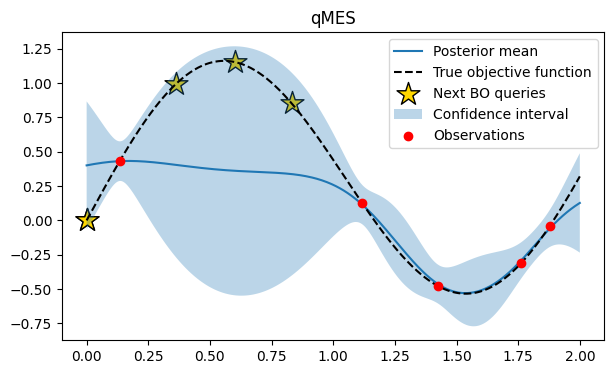

In [12]:
from botorch.acquisition.max_value_entropy_search import qMaxValueEntropy

candidate_set = torch.rand(1000, bounds.size(1)).to(device=device, dtype=dtype)
candidate_set = bounds[0] + (bounds[1] - bounds[0]) * candidate_set

acqf = qMaxValueEntropy(
    model=model,
    candidate_set=candidate_set,
)

candidates, _ = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=q,
    num_restarts=10,
    raw_samples=64,
    sequential=True,       
)

plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("qMES")
plt.legend()
plt.show()


# 6.2 GIBBON

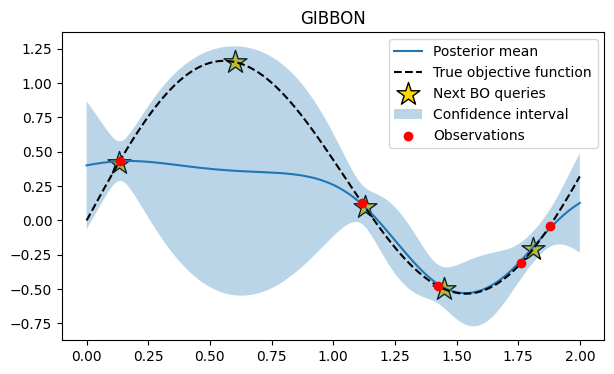

In [13]:
from botorch.acquisition.max_value_entropy_search import qLowerBoundMaxValueEntropy

candidate_set = torch.rand(1000, bounds.size(1)).to(device=device, dtype=dtype)
candidate_set = bounds[0] + (bounds[1] - bounds[0]) * candidate_set

acqf = qLowerBoundMaxValueEntropy(
    model=model,
    candidate_set=candidate_set,
)

candidates, _ = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=q,
    num_restarts=10,
    raw_samples=64,
    sequential=True,       
)

plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("GIBBON")
plt.legend()
plt.show()


# 7.1 BEEBO                (one-dimensional functions are not supported)

/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([-60.0644], device='cuda:0', dtype=torch.float64), std = tensor([43.9414], device='cuda:0', dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


candidates: tensor([[ 5.5446,  4.4684],
        [-3.2046,  1.6550],
        [-3.2694, 14.4346],
        [-4.0024,  6.6178],
        [-3.2699, 14.4344]], device='cuda:0', dtype=torch.float64)


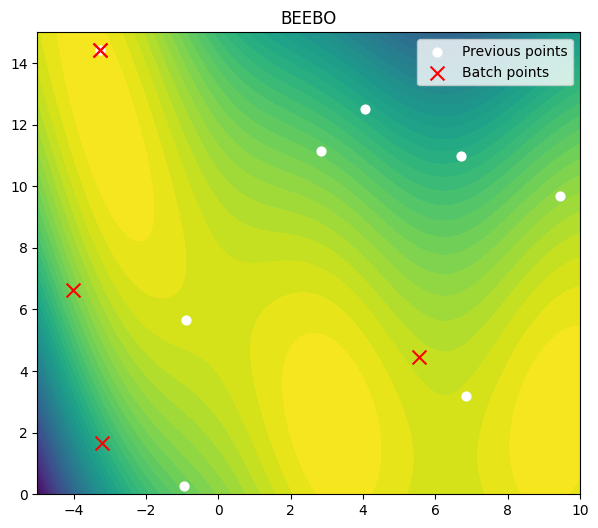

In [20]:
from beebo import BatchedEnergyEntropyBO
from botorch.test_functions import Branin

branin = Branin(negate=True).to(device=device, dtype=dtype)
bounds = branin.bounds.to(device=device, dtype=dtype)

n_init = 8
train_X = bounds[0] + (bounds[1] - bounds[0]) * torch.rand(n_init, 2, device=device, dtype=dtype)
train_X = train_X.to(device=device, dtype=dtype)
train_Y = branin(train_X).unsqueeze(-1)
train_Y = train_Y.to(device=device, dtype=dtype)


# ========== 2. Grid (for plotting true function) ==========
grid_size = 100
x1 = torch.linspace(bounds[0, 0], bounds[1, 0], grid_size, device=device, dtype=dtype)
x2 = torch.linspace(bounds[0, 1], bounds[1, 1], grid_size, device=device, dtype=dtype)
X1, X2 = torch.meshgrid(x1, x2, indexing="ij")
X_grid = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=-1)
Y_true = branin(X_grid).reshape(grid_size, grid_size).to(device=device, dtype=dtype)


model = SingleTaskGP(train_X, train_Y).to(device=device, dtype=dtype)
mll = ExactMarginalLogLikelihood(model.likelihood, model).to(device=device, dtype=dtype)
fit_gpytorch_mll(mll).to(device=device, dtype=dtype)

amplitude = model.covar_module.outputscale.item() # get the GP's kernel amplitude

acqf = BatchedEnergyEntropyBO(
    model=model, # a gaussian process model.
    temperature=1.0, 
    kernel_amplitude=amplitude,
    energy_function='sum', # "sum" for meanBEEBO, "softmax" for maxBEEBO
    logdet_method='svd', # LinAlg: how to compute log determinants
    augment_method='naive', # LinAlg: how to perform the train data augmentation
    ).to(device=device, dtype=dtype)

with torch.no_grad():
    cqf_values = acqf(train_X.unsqueeze(1))  


candidates, _= optimize_acqf(
    acq_function=acqf, 
    q=5, 
    num_restarts=10, 
    bounds=bounds, # the bounds of the optimization problem
    raw_samples=100, 
    )   

print('candidates:', candidates)

plt.figure(figsize=(7, 6))
plt.contourf(X1.cpu().numpy(), X2.cpu().numpy(), Y_true.cpu().numpy(), levels=50, cmap="viridis")
plt.scatter(
    train_X[:, 0].cpu().numpy(),
    train_X[:, 1].cpu().numpy(),
    c="white",
    s=40,
label="Previous points",
)
plt.scatter(
    candidates[:, 0].cpu().numpy(),
    candidates[:, 1].cpu().numpy(),
    marker="x",
    s=100,
    c='red',
    label="Batch points",
)
plt.legend()
plt.title("BEEBO")
plt.show()